---
tags: [algorithm, encoding, primitive]
---

# Möttönen Amplitude Encoding

This notebook prepares real and complex amplitude vectors with Qamomile's
explicit Möttönen construction, verifies the resulting states and gate counts,
and shows when to choose the method-specific API instead of generic amplitude
encoding.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

In [2]:
import numpy as np
from qiskit.quantum_info import Statevector

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.stdlib import (
    amplitude_encoding,
    mottonen_amplitude_encoding,
    mottonen_amplitude_encoding_from_angles,
)
from qamomile.linalg import (
    compute_mottonen_amplitude_encoding_ry_angles,
    compute_mottonen_amplitude_encoding_rz_angles,
)
from qamomile.qiskit import QiskitTranspiler

## Background

**Amplitude encoding** prepares an $n$-qubit state from a unit-norm complex
vector $a \in \mathbb{C}^{2^n}$:

$$
|0\rangle^{\otimes n}
\longmapsto
|\psi\rangle
= \sum_{i=0}^{2^n - 1} a_i |i\rangle.
$$

Möttönen amplitude encoding is one algorithm that realizes this
state-preparation map. Other algorithms can realize the same map, so Qamomile
provides one API that explicitly requests Möttönen's method and another that
requests state preparation without prescribing the method:

- `mottonen_amplitude_encoding(...)` explicitly requests Qamomile's Möttönen
  construction. Use it when the decomposition, resource counts, or synthesis
  method are part of the program's intent.
- `amplitude_encoding(...)` expresses only the target state. A backend may use
  its native state-preparation operation. Qamomile currently uses the
  Möttönen construction as the portable fallback, but that fallback is not a
  method guarantee of the generic API.

The explicit implementation follows the uniformly controlled rotation
construction of Möttönen, Vartiainen, Bergholm, and Salomaa
{cite:p}`10.48550/arXiv.quant-ph/0407010`. The paper treats the more general
arbitrary-state transformation $|a\rangle \to |b\rangle$; Qamomile implements
the state-preparation half with the input fixed to $|0\rangle^{\otimes n}$.

:::{note}
If the input qubits are not in $|0\rangle^{\otimes n}$, neither API
generally guarantees the output state.
:::

## Problem Settings

We use two qubits and compare the prepared statevector with three normalized
targets:

- a positive real vector $(1, 2, 3, 4)$,
- a signed real vector $(1, -1, 1, -1)$, and
- a complex vector $(1, 1+i, 1-i, 2i)$.

State fidelity is phase-invariant, so it verifies the intended physical state
even if a backend chooses a different global phase.

In [3]:
transpiler = QiskitTranspiler()
executor = transpiler.executor()

ATOL_STATEVECTOR = 1e-8
ATOL_SHOT = 0.05


def fidelity(prepared: np.ndarray, target: np.ndarray) -> float:
    """Return the phase-invariant fidelity between two statevectors."""
    return float(np.abs(np.vdot(prepared, target)) ** 2)


def normalize(amplitudes: list[float] | list[complex]) -> np.ndarray:
    """Return a unit-norm copy of an amplitude vector."""
    if any(isinstance(value, complex) for value in amplitudes):
        array = np.asarray(amplitudes, dtype=complex)
    else:
        array = np.asarray(amplitudes, dtype=float)
    return array / np.linalg.norm(array)


def statevector_of(kernel: qmc.QKernel, **bindings) -> np.ndarray:
    """Transpile a kernel and return its final statevector."""
    circuit = transpiler.to_circuit(kernel, bindings=bindings or None)
    stripped = circuit.remove_final_measurements(inplace=False)
    assert stripped is not None
    return Statevector.from_instruction(stripped).data


amps_real = [1.0, 2.0, 3.0, 4.0]
amps_signed = [1.0, -1.0, 1.0, -1.0]
amps_complex = [1 + 0j, 1 + 1j, 1 - 1j, 0 + 2j]

## Algorithm

The Möttönen state-preparation construction has two cascades:

1. Uniformly controlled $R_y$ rotations distribute the magnitudes $|a_i|$
   across computational-basis states. For real vectors, signed rotation angles
   also encode negative amplitudes.
2. Uniformly controlled $R_z$ rotations restore relative phases. Qamomile
   omits this cascade when every amplitude has zero imaginary part.

Each uniformly controlled rotation is decomposed into elementary rotations and
`CNOT` gates with the Gray-code construction. For Qamomile's
$|0\rangle^{\otimes n} \to |\psi\rangle$ specialization, the resulting counts
are:

| Input | Rotations | `CNOT` gates |
|---|---:|---:|
| Real | $2^n - 1$ | $2^n - 2$ |
| Complex | $2(2^n - 1)$ | $2(2^n - 2)$ |

A $k$-controlled uniformly controlled rotation costs $2^k$ elementary
rotations and $2^k$ `CNOT` gates. Summing the stages for
$k = 0, 1, \ldots, n-1$ gives the formulas above; the uncontrolled stage is
`CNOT`-free. The larger counts quoted in the paper's abstract apply to the
full arbitrary-input transformation $|a\rangle \to |b\rangle$, rather than the
state-preparation half implemented here. Qamomile also retains the plain
per-stage decomposition instead of applying inter-cascade `CNOT`
cancellation.

## Implementation

### Bind amplitudes at transpile time

A real or signed-real amplitude vector can be declared as a qkernel
`Vector[Float]` argument. When concrete values are supplied through
`bindings` at transpile time, Qamomile automatically normalizes the
amplitudes and generates the Möttönen angles and gate sequence.

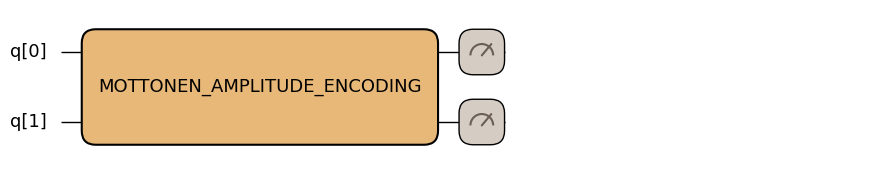

In [4]:
@qmc.qkernel
def prepare_from_amplitudes(
    amplitudes: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = mottonen_amplitude_encoding(q, amplitudes)
    return qmc.measure(q)


prepare_from_amplitudes.draw(fold_loops=False, amplitudes=amps_real)

The unexpanded circuit keeps the method-specific operation as one composite
gate. Passing `expand_composite=True` exposes its elementary $R_y$, $R_z$, and
`CNOT` sequence. The real circuit has no $R_z$ phase cascade.

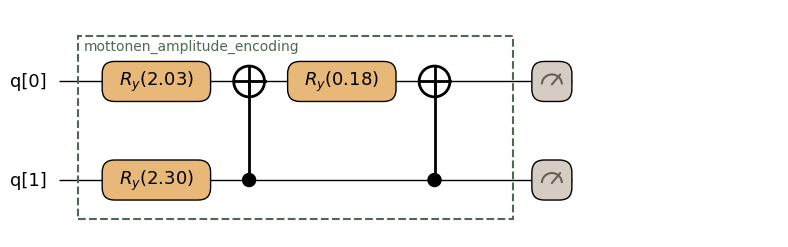

In [5]:
prepare_from_amplitudes.draw(
    fold_loops=False,
    expand_composite=True,
    amplitudes=amps_real,
)

Because `Vector[Float]` holds only real values, a complex amplitude vector
cannot be bound directly. For complex input, compute the Möttönen angles
outside the qkernel and pass them to the angle API below as two
`Vector[Float]` arguments.

Leaving `amplitudes` in `parameters` is also invalid because operations
such as `atan2(|a_1|, |a_0|)` need concrete values during tracing. For a
circuit that can be rebound at runtime, precompute the Möttönen angles and use
the angle API below.

In [6]:
try:
    transpiler.transpile(prepare_from_amplitudes, parameters=["amplitudes"])
except ValueError as exc:
    print(f"ValueError: {exc}")
    raised = True
else:
    raised = False
assert raised, "expected ValueError when amplitudes is a runtime parameter"

ValueError: mottonen_amplitude_encoding received a Vector[Float] handle without concrete values at trace time. Bind it via transpiler.transpile(kernel, bindings={...}) for compile-time amplitudes, or use mottonen_amplitude_encoding_from_angles with parameters=[...] for runtime-parametric angles.


### Compile once with runtime-rebindable angles

`mottonen_amplitude_encoding_from_angles(...)` takes the Möttönen angles
computed by the caller. Because those angles can remain runtime parameters, one
compiled circuit can prepare many amplitude vectors. The function emits the
elementary rotations and `CNOT` gates directly rather than wrapping them in a
composite operation.

The previous name `amplitude_encoding_from_angles(...)` remains available as a
compatibility wrapper. New code should use the method-specific name because the
supplied angles and emitted gate sequence are specifically Möttönen's.

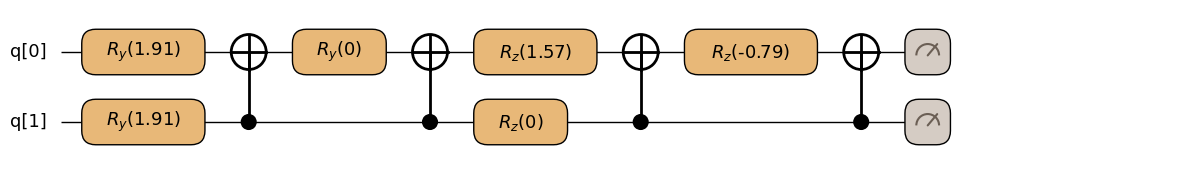

In [7]:
@qmc.qkernel
def prepare_from_angles(
    ry_angles: qmc.Vector[qmc.Float], rz_angles: qmc.Vector[qmc.Float]
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = mottonen_amplitude_encoding_from_angles(q, ry_angles, rz_angles)
    return qmc.measure(q)


complex_ry_angles = compute_mottonen_amplitude_encoding_ry_angles(amps_complex).tolist()
complex_rz_angles = compute_mottonen_amplitude_encoding_rz_angles(amps_complex).tolist()

prepare_from_angles.draw(
    fold_loops=False,
    ry_angles=complex_ry_angles,
    rz_angles=complex_rz_angles,
)

### Build kernels for resource checks

These helpers create real and complex Möttönen circuits over several register
sizes. Using the explicit API ensures that backend-native state preparation
cannot change the construction whose resources we are measuring.

In [8]:
def make_real_kernel(n_qubits: int) -> qmc.QKernel:
    """Build a real-input Möttönen state-preparation kernel."""

    @qmc.qkernel
    def kernel(amplitudes: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n_qubits, "q")
        q = mottonen_amplitude_encoding(q, amplitudes)
        return qmc.measure(q)

    return kernel


def make_complex_kernel(n_qubits: int) -> qmc.QKernel:
    """Build a complex-input Möttönen state-preparation kernel."""

    @qmc.qkernel
    def kernel(
        ry_angles: qmc.Vector[qmc.Float],
        rz_angles: qmc.Vector[qmc.Float],
    ) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n_qubits, "q")
        q = mottonen_amplitude_encoding_from_angles(q, ry_angles, rz_angles)
        return qmc.measure(q)

    return kernel

## Result

### State fidelity

Real and signed-real inputs use amplitude `bindings`, while the complex
input uses angle `bindings`. All three reproduce their normalized target up
to global phase.

In [9]:
for label, target_amplitudes in (
    ("real", amps_real),
    ("signed real", amps_signed),
):
    prepared = statevector_of(
        prepare_from_amplitudes,
        amplitudes=target_amplitudes,
    )
    target = normalize(target_amplitudes)
    value = fidelity(prepared, target)
    print(f"{label:>11s} fidelity = {value:.8f}")
    assert np.isclose(value, 1.0, atol=ATOL_STATEVECTOR)

prepared_complex = statevector_of(
    prepare_from_angles,
    ry_angles=complex_ry_angles,
    rz_angles=complex_rz_angles,
)
complex_fidelity = fidelity(prepared_complex, normalize(amps_complex))
print(f"{'complex':>11s} fidelity = {complex_fidelity:.8f}")
assert np.isclose(complex_fidelity, 1.0, atol=ATOL_STATEVECTOR)

       real fidelity = 1.00000000
signed real fidelity = 1.00000000
    complex fidelity = 1.00000000


### Runtime rebinding

The compiled two-qubit complex circuit has six runtime rotation parameters:
three $R_y$ angles and three $R_z$ angles. We reuse it for three target vectors
and compare the sampled probabilities with $|a_i|^2$.

In [10]:
executable = transpiler.transpile(
    prepare_from_angles, parameters=["ry_angles", "rz_angles"]
)
n_runtime_params = len(executable.compiled_quantum[0].circuit.parameters)
print(f"runtime parameters in compiled circuit: {n_runtime_params}")
assert n_runtime_params == 2 * (2**2 - 1)

shots = 8192
for trial_amplitudes in (
    [1.0, 0.0, 0.0, 1.0],
    [3.0, 4.0, 0.0, 0.0],
    [1 + 0j, 1j, -1 + 0j, -1j],
):
    ry_values = compute_mottonen_amplitude_encoding_ry_angles(trial_amplitudes).tolist()
    rz_values = compute_mottonen_amplitude_encoding_rz_angles(trial_amplitudes).tolist()
    counts = (
        executable.sample(
            executor,
            shots=shots,
            bindings={"ry_angles": ry_values, "rz_angles": rz_values},
        )
        .result()
        .results
    )
    observed = np.zeros(4)
    for bits, count in counts:
        index = sum(int(bit) << i for i, bit in enumerate(bits))
        observed[index] = count / shots
    expected_probabilities = np.abs(normalize(trial_amplitudes)) ** 2
    max_deviation = float(np.max(np.abs(observed - expected_probabilities)))
    print(f"amps={str(trial_amplitudes):<48s} max|p_obs - p_exp| = {max_deviation:.4f}")
    assert max_deviation < ATOL_SHOT

runtime parameters in compiled circuit: 6
amps=[1.0, 0.0, 0.0, 1.0]                             max|p_obs - p_exp| = 0.0016
amps=[3.0, 4.0, 0.0, 0.0]                             max|p_obs - p_exp| = 0.0005


amps=[(1+0j), 1j, (-1+0j), (-0-1j)]                   max|p_obs - p_exp| = 0.0022


### Resource formula

`estimate_resources()` expands the composite metadata and agrees with the
Möttönen formulas for every tested register size.

In [11]:
print(f"{'n':>3s} | {'real(rot/CNOT)':>16s} | {'complex(rot/CNOT)':>20s}")
print(f"{'---':>3s} | {'---':>16s} | {'---':>20s}")
for n_qubits in (2, 3, 4, 5):
    real_amplitudes = np.ones(2**n_qubits).tolist()
    complex_amplitudes = (np.ones(2**n_qubits) + 1j * np.arange(2**n_qubits)).tolist()
    real_resources = qmc.estimate_resources(
        make_real_kernel(n_qubits).build(amplitudes=real_amplitudes)
    )
    complex_resources = qmc.estimate_resources(
        make_complex_kernel(n_qubits).build(
            ry_angles=compute_mottonen_amplitude_encoding_ry_angles(
                complex_amplitudes
            ).tolist(),
            rz_angles=compute_mottonen_amplitude_encoding_rz_angles(
                complex_amplitudes
            ).tolist(),
        )
    )
    real_rotations = int(real_resources.gates.rotation_gates)
    real_cnots = int(real_resources.gates.two_qubit)
    complex_rotations = int(complex_resources.gates.rotation_gates)
    complex_cnots = int(complex_resources.gates.two_qubit)
    print(
        f"{n_qubits:>3d} | "
        f"{f'{real_rotations} / {real_cnots}':>16s} | "
        f"{f'{complex_rotations} / {complex_cnots}':>20s}"
    )

    assert real_rotations == 2**n_qubits - 1
    assert real_cnots == 2**n_qubits - 2
    assert complex_rotations == 2 * (2**n_qubits - 1)
    assert complex_cnots == 2 * (2**n_qubits - 2)

  n |   real(rot/CNOT) |    complex(rot/CNOT)
--- |              --- |                  ---
  2 |            3 / 2 |                6 / 4
  3 |            7 / 6 |              14 / 12


  4 |          15 / 14 |              30 / 28
  5 |          31 / 30 |              62 / 60


Both rotation and `CNOT` counts grow as $O(2^n)$ in the number of qubits.
This exponential circuit cost is an important constraint when choosing
amplitude encoding for larger classical vectors.

### Composition with an observable

The explicit state-preparation operation composes with the rest of a qkernel.
For $(1, 2, 3, 4)$ in Qamomile's little-endian ordering,

$$
\langle Z_0 \rangle
= \frac{1 + 9 - 4 - 16}{30}
= -\frac{1}{3}.
$$

In [12]:
@qmc.qkernel
def expval_kernel(
    amplitudes: qmc.Vector[qmc.Float],
    observable: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(2, "q")
    q = mottonen_amplitude_encoding(q, amplitudes)
    return qmc.expval(q, observable)


hamiltonian = qm_o.Z(0) + 0.0 * qm_o.Z(1)
expval_executable = transpiler.transpile(
    expval_kernel,
    bindings={"amplitudes": amps_real, "observable": hamiltonian},
)
expval_result = expval_executable.run(executor).result()
print(f"<Z_0> = {float(expval_result):+.6f}")
assert np.isclose(float(expval_result), -1.0 / 3.0, atol=ATOL_STATEVECTOR)

<Z_0> = -0.333333


## Qamomile Built-ins

Qamomile provides both generic and method-specific state-preparation helpers.
Choose between them according to whether only the prepared state or also the
synthesis method belongs to the program's contract:

| Goal | API |
|---|---|
| Prepare a target state and allow backend-native synthesis | `amplitude_encoding(q, amplitudes)` |
| Require Qamomile's Möttönen construction | `mottonen_amplitude_encoding(q, amplitudes)` |
| Bind real amplitudes at transpile time while retaining the Möttönen method | `mottonen_amplitude_encoding(q, amps)` with `bindings={"amps": [...]}` |
| Reuse one Möttönen circuit with runtime angle bindings | `mottonen_amplitude_encoding_from_angles(q, ry, rz)` with `parameters=[...]` |
| Keep existing code working during migration | `amplitude_encoding_from_angles(...)` (compatibility wrapper) |

The generic and explicit amplitude APIs prepare the same target state, but a
backend is free to realize only the generic operation with a different
state-preparation synthesis.

In [13]:
@qmc.qkernel
def prepare_generic(
    amplitudes: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amplitudes)
    return qmc.measure(q)


generic_state = statevector_of(prepare_generic, amplitudes=amps_real)
assert np.isclose(
    fidelity(generic_state, normalize(amps_real)), 1.0, atol=ATOL_STATEVECTOR
)

## Summary

In this notebook, we:

- Passed real amplitudes and Möttönen angles as qkernel arguments and checked
  unit fidelity for real and complex states.
- Verified the $O(2^n)$ rotation and `CNOT` counts of Qamomile's construction.
- Reused one compiled circuit through the canonical
  `mottonen_amplitude_encoding_from_angles(...)` API.
- Distinguished method-agnostic `amplitude_encoding(...)` from the
  method-specific APIs used when Möttönen synthesis is part of the intent.